In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt

Меняем формат данных из изображения нормализует значения пикселей

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),           # [0,255] → [0,1]
])

Это создание объектов датасета

In [ ]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.81MB/s]


Деление на train/val

In [ ]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

Случайно разбивает исходный train_dataset на два поднабора

In [ ]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # 1 блок
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)

        # 2 блок
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.bn2 = nn.BatchNorm2d(64)

        # регуляризация
        self.dropout = nn.Dropout(0.25)

        # классификатор
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()
# Определяем как данные проходят через сеть.
    def forward(self, x):
        # Блок 1
        x = self.pool(self.relu(self.bn1(self.conv1(x))))

        # Блок 2
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        x = self.dropout(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Dense
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
device = torch.device("cuda")

model = Net().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
num_epochs = 15

train_acc_history = []
val_acc_history = []

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad() # обнуляем градиенты

        outputs = model(X)
        loss = criterion(outputs, y)

        loss.backward()  # считаем градиенты
        optimizer.step() # обновляем веса


        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    train_acc = correct / total
    train_acc_history.append(train_acc)

    # validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad(): # Градиенты здесь не считаются, потому что это этап валидации
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)
            _, predicted = torch.max(outputs, 1)

            total += y.size(0)
            correct += (predicted == y).sum().item()

    val_acc = correct / total
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

Epoch 1: train_acc=0.9517, val_acc=0.9778
Epoch 2: train_acc=0.9809, val_acc=0.9842
Epoch 3: train_acc=0.9850, val_acc=0.9839
Epoch 4: train_acc=0.9881, val_acc=0.9884
Epoch 5: train_acc=0.9911, val_acc=0.9889
Epoch 6: train_acc=0.9920, val_acc=0.9893
Epoch 7: train_acc=0.9927, val_acc=0.9882
Epoch 8: train_acc=0.9931, val_acc=0.9887
Epoch 9: train_acc=0.9945, val_acc=0.9901
Epoch 10: train_acc=0.9949, val_acc=0.9912
Epoch 11: train_acc=0.9945, val_acc=0.9901
Epoch 12: train_acc=0.9954, val_acc=0.9885
Epoch 13: train_acc=0.9959, val_acc=0.9906
Epoch 14: train_acc=0.9959, val_acc=0.9873
Epoch 15: train_acc=0.9959, val_acc=0.9900


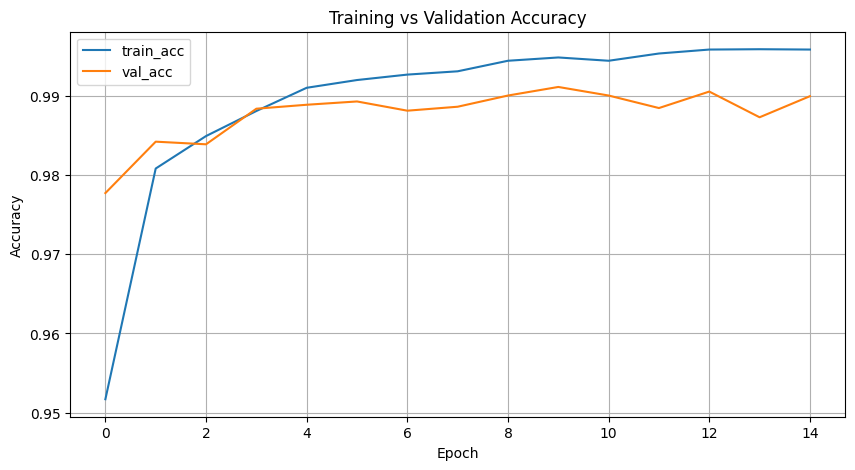

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(train_acc_history, label='train_acc')
plt.plot(val_acc_history, label='val_acc')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.grid()

plt.show()